# Multimodal Housing Price Prediction (Images + Tabular Data)

**Task:** Predict house sale price using a CNN on house photos combined with structured tabular features (beds, baths, sqft, location).

**Dataset:** [House Prices and Images (SoCal)](https://www.kaggle.com/datasets/ted8080/house-prices-and-images-socal) - a public Kaggle dataset with ~15k Southern California listings, each with a photo and tabular fields (`bed`, `bath`, `sqft`, `city`, `price`).

I picked this one over building a custom scraped dataset since it already pairs one representative image per listing with clean tabular data, which is exactly the setup this task needs.

Before running: add the dataset to this notebook via **Add Data -> search "House Prices and Images (SoCal)"** on the right sidebar. The path below assumes the default Kaggle mount location.


In [1]:
!pip install -q torch torchvision scikit-learn pandas matplotlib


## 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


## 2. Load the tabular data + check image paths

The SoCal dataset ships a `socal2.csv` with one row per house and an `image_id` column that maps to a jpg in `socal2/socal_pics/`. Adjust `DATA_DIR` if Kaggle mounts it under a different folder name - just check the sidebar path once you add the dataset.

In [4]:
DATA_DIR = "/kaggle/input/datasets/ted8080/house-prices-and-images-socal"
CSV_PATH = os.path.join(DATA_DIR, "socal2.csv")
IMG_DIR = os.path.join(DATA_DIR, "socal2/socal_pics")

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()


(15474, 8)


,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100


In [5]:
# basic sanity check that images actually exist for the rows we have
sample_img = os.path.join(IMG_DIR, f"{df.iloc[0]['image_id']}.jpg")
print(sample_img, "exists:", os.path.exists(sample_img))


/kaggle/input/datasets/ted8080/house-prices-and-images-socal/socal2/socal_pics/0.jpg exists: True


A quick look at price distribution - housing prices are heavily right-skewed (a handful of multi-million dollar listings drag the tail out), so I'll train on `log(price)` instead of raw price and convert back before computing the final MAE/RMSE. That keeps the loss from being dominated by a few outlier mansions.

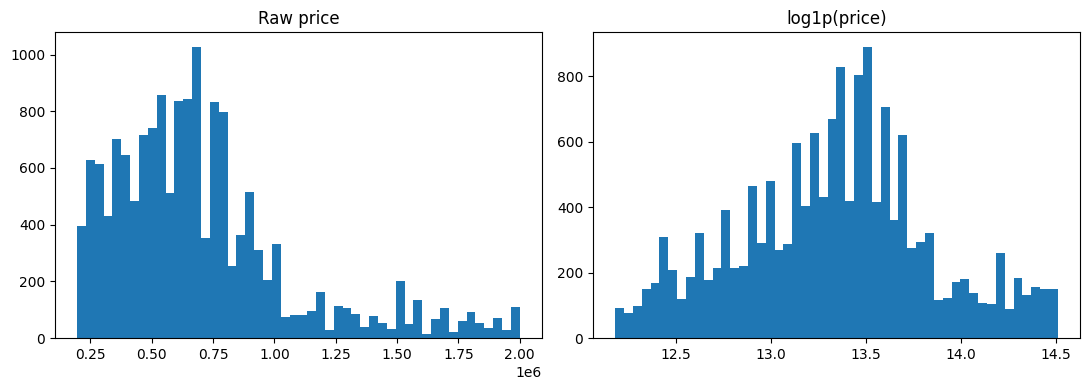

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["price"], bins=50)
axes[0].set_title("Raw price")
axes[1].hist(np.log1p(df["price"]), bins=50)
axes[1].set_title("log1p(price)")
plt.tight_layout()
plt.show()


## 3. Clean up and prep the tabular features

Dropping a handful of obviously broken rows (zero/negative sqft or price, missing images) and encoding `citi` as a categorical feature. Keeping it simple: `bed`, `bath`, `sqft`, and city.

In [7]:
df = df[(df["sqft"] > 0) & (df["price"] > 0) & (df["bed"] > 0) & (df["bath"] > 0)].copy()

# make sure every remaining row actually has an image file
df["img_path"] = df["image_id"].apply(lambda x: os.path.join(IMG_DIR, f"{x}.jpg"))
df = df[df["img_path"].apply(os.path.exists)].reset_index(drop=True)

print("rows after cleaning:", len(df))

city_encoder = LabelEncoder()
df["city_enc"] = city_encoder.fit_transform(df["citi"].astype(str))

df["log_price"] = np.log1p(df["price"])

tabular_cols = ["bed", "bath", "sqft", "city_enc"]
df.head()


rows after cleaning: 15463


,image_id,street,citi,n_citi,bed,bath,sqft,price,img_path,city_enc,log_price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900,/kaggle/input/datasets/ted8080/house-prices-an...,317,12.215533
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500,/kaggle/input/datasets/ted8080/house-prices-an...,48,12.339296
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950,/kaggle/input/datasets/ted8080/house-prices-an...,152,12.520705
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000,/kaggle/input/datasets/ted8080/house-prices-an...,48,12.765691
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100,/kaggle/input/datasets/ted8080/house-prices-an...,55,12.861261


In [8]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

# fit the scaler only on train, then apply everywhere - standard practice to avoid leakage
tab_scaler = StandardScaler()
train_df.loc[:, tabular_cols] = tab_scaler.fit_transform(train_df[tabular_cols])
val_df.loc[:, tabular_cols] = tab_scaler.transform(val_df[tabular_cols])
test_df.loc[:, tabular_cols] = tab_scaler.transform(test_df[tabular_cols])


train: 12370 val: 1546 test: 1547


/tmp/ipykernel_59/2945055400.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.49010036 -0.49010036 -1.46057282 ... -1.46057282 -0.49010036
  0.4803721 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, tabular_cols] = tab_scaler.fit_transform(train_df[tabular_cols])
/tmp/ipykernel_59/2945055400.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.86166359 -1.11135554 -0.39655113 ... -1.07218818 -0.62763858
  1.07222507]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, tabular_cols] = tab_scaler.fit_transform(train_df[tabular_cols])
/tmp/ipykernel_59/2945055400.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.87725112  0.35141997 -1.58952421 ... 

## 4. PyTorch Dataset combining image + tabular features

Each item returns the transformed image tensor, the tabular feature vector, and the (log) price target.

In [9]:
IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats, matches the pretrained CNN
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HousingDataset(Dataset):
    def __init__(self, dataframe, tabular_cols, transform):
        self.df = dataframe.reset_index(drop=True)
        self.tabular_cols = tabular_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["img_path"]).convert("RGB")
        image = self.transform(image)

        tabular = torch.tensor(row[self.tabular_cols].values.astype(np.float32))
        target = torch.tensor(row["log_price"], dtype=torch.float32)

        return image, tabular, target


train_dataset = HousingDataset(train_df, tabular_cols, train_transform)
val_dataset = HousingDataset(val_df, tabular_cols, eval_transform)
test_dataset = HousingDataset(test_df, tabular_cols, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


## 5. Multimodal model: CNN branch + tabular branch -> fusion

- **Image branch**: a pretrained ResNet18 (ImageNet weights) with its final classification layer stripped off, used as a feature extractor. I froze the early conv layers and only fine-tune the last block, which is usually enough for a dataset this size and keeps training fast.
- **Tabular branch**: a small MLP on the 4 tabular features.
- **Fusion**: concatenate both embeddings and pass through a final MLP head that outputs a single number (log price).

In [10]:
class MultimodalHousingModel(nn.Module):
    def __init__(self, num_tabular_features, image_embed_dim=128, tabular_embed_dim=32):
        super().__init__()

        # --- image branch ---
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # freeze everything except the last residual block, fine-tune that + our new head
        for name, param in resnet.named_parameters():
            if not name.startswith("layer4"):
                param.requires_grad = False

        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-1])  # drop the final fc layer
        self.image_fc = nn.Linear(resnet.fc.in_features, image_embed_dim)

        # --- tabular branch ---
        self.tabular_net = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.ReLU(),
            nn.Linear(64, tabular_embed_dim),
            nn.ReLU(),
        )

        # --- fusion head ---
        self.fusion_head = nn.Sequential(
            nn.Linear(image_embed_dim + tabular_embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, image, tabular):
        img_feat = self.cnn_backbone(image).flatten(1)
        img_feat = torch.relu(self.image_fc(img_feat))

        tab_feat = self.tabular_net(tabular)

        fused = torch.cat([img_feat, tab_feat], dim=1)
        out = self.fusion_head(fused)
        return out.squeeze(1)


model = MultimodalHousingModel(num_tabular_features=len(tabular_cols)).to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s] 


## 6. Training loop

Using plain MSE loss on log price (Huber loss would also be a reasonable choice here to further dampen outlier sensitivity, but MSE + log-transform already does most of that job). Tracking validation MAE/RMSE (converted back to real dollars) each epoch so I can see if the model's actually learning something useful, not just minimizing an abstract log-space loss.

In [11]:
def log_to_price(log_vals):
    return np.expm1(log_vals)


def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, tabular, targets in loader:
            images, tabular = images.to(device), tabular.to(device)
            preds = model(images, tabular).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(targets.numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # convert back from log-price to actual dollars before computing MAE/RMSE,
    # since we care about real-world dollar error, not log-space error
    price_preds = log_to_price(all_preds)
    price_targets = log_to_price(all_targets)

    mae = mean_absolute_error(price_targets, price_preds)
    rmse = np.sqrt(mean_squared_error(price_targets, price_preds))
    return mae, rmse


optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
criterion = nn.MSELoss()

NUM_EPOCHS = 10
history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for images, tabular, targets in train_loader:
        images, tabular, targets = images.to(device), tabular.to(device), targets.to(device)

        optimizer.zero_grad()
        preds = model(images, tabular)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)
    val_mae, val_rmse = evaluate(model, val_loader)
    history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_mae": val_mae, "val_rmse": val_rmse})

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - train_loss: {train_loss:.4f} - val_MAE: ${val_mae:,.0f} - val_RMSE: ${val_rmse:,.0f}")


Epoch 1/10 - train_loss: 24.2428 - val_MAE: $340,955 - val_RMSE: $490,694
Epoch 2/10 - train_loss: 3.2265 - val_MAE: $275,242 - val_RMSE: $388,860
Epoch 3/10 - train_loss: 2.8606 - val_MAE: $258,330 - val_RMSE: $372,564
Epoch 4/10 - train_loss: 2.8116 - val_MAE: $271,987 - val_RMSE: $386,902
Epoch 5/10 - train_loss: 2.6726 - val_MAE: $226,079 - val_RMSE: $325,770
Epoch 6/10 - train_loss: 2.6636 - val_MAE: $247,913 - val_RMSE: $360,045
Epoch 7/10 - train_loss: 2.7604 - val_MAE: $249,345 - val_RMSE: $361,086
Epoch 8/10 - train_loss: 2.7072 - val_MAE: $248,685 - val_RMSE: $361,595
Epoch 9/10 - train_loss: 2.6902 - val_MAE: $235,345 - val_RMSE: $340,378
Epoch 10/10 - train_loss: 2.6905 - val_MAE: $230,724 - val_RMSE: $307,974


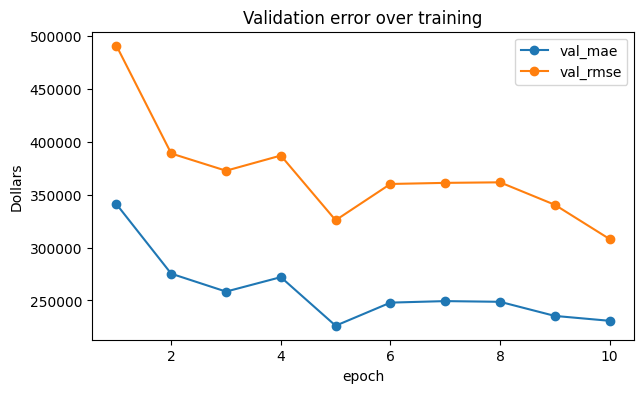

In [12]:
history_df = pd.DataFrame(history)
history_df.plot(x="epoch", y=["val_mae", "val_rmse"], marker="o", figsize=(7, 4))
plt.ylabel("Dollars")
plt.title("Validation error over training")
plt.show()


## 7. Final evaluation on the held-out test set

In [13]:
test_mae, test_rmse = evaluate(model, test_loader)
print(f"Test MAE:  ${test_mae:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")


Test MAE:  $244,322.38
Test RMSE: $614,298.93


## 8. Baseline comparison (tabular-only)

To sanity-check that the images are actually pulling their weight, it's worth comparing against a tabular-only baseline. If the multimodal model doesn't clearly beat this, the image branch isn't adding much and it's worth questioning whether the extra complexity is justified.

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(train_df[tabular_cols], train_df["log_price"])

rf_preds_log = rf.predict(test_df[tabular_cols])
rf_preds = log_to_price(rf_preds_log)
rf_targets = log_to_price(test_df["log_price"].values)

rf_mae = mean_absolute_error(rf_targets, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(rf_targets, rf_preds))

print(f"Tabular-only RF baseline - MAE: ${rf_mae:,.2f}  RMSE: ${rf_rmse:,.2f}")
print(f"Multimodal model         - MAE: ${test_mae:,.2f}  RMSE: ${test_rmse:,.2f}")


Tabular-only RF baseline - MAE: $136,812.41  RMSE: $236,336.89
Multimodal model         - MAE: $244,322.38  RMSE: $614,298.93


## 9. Save the trained model

In [15]:
torch.save(model.state_dict(), "multimodal_housing_model.pt")
print("saved model weights")


saved model weights


### Notes / things I'd improve with more time
- Only used one photo per listing (dataset default) - real listings usually have several angles (exterior, kitchen, etc.), and averaging embeddings across multiple images per house would probably help
- Didn't unfreeze the whole ResNet - with more GPU budget, fully fine-tuning (with a lower LR) might squeeze out more from the image branch
- The tabular-only Random Forest baseline is there specifically to check the images are earning their keep - worth reporting both numbers, not just the multimodal one, since it's the honest way to show the image branch's actual contribution
- Could also try a gradient boosting model (XGBoost/LightGBM) fed with both the raw tabular features *and* the CNN embeddings as extra columns, as an alternative fusion strategy to the neural fusion head used here
